---
title: Advanced Statistical Data Analysis
authors:
  - name: Anna Drewek
    affiliation: ZHAW School of Engineering
  - name: Andreas Ruckstuhl
    affiliation: ZHAW School of Engineering
exports:
- format: pdf
  template: https://github.com/marbetschar/plain_latex_article/archive/refs/heads/main.zip
  output: Advanced-Statistical-Data-Analysis.pdf
  id: advanced-statistical-data-analysis-pdf
downloads:
  - id: advanced-statistical-data-analysis-pdf
    title: Download as PDF
---

In [22]:
# Install BiocManager (if not already installed)
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Install graph and RBGL from Bioconductor
BiocManager::install(c("graph", "RBGL", "Rgraphviz"))

install.packages("gRbase")
install.packages("pcalg")

library(gRbase)

set.seed(123)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'graph' 'RBGL' 'Rgraphviz'”
Warning message in .available.both(repos, method, ...):
“Some listed binary packages have no source”
Old packages: 'boot', 'class', 'cluster', 'codetools', 'DEoptimR', 'foreign',
  'igraph', 'KernSmooth', 'lattice', 'MASS', 'Matrix', 'mgcv', 'nlme', 'nnet',
  'RcppArmadillo', 'rpart', 'spatial', 'survival', 'withr'




The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpkDW9Vx/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpkDW9Vx/downloaded_packages


# Overview

```{prf:definition} Statistical Data Analysis}
Statistical data analysis is the science of collecting, exploring, and presenting (large amounts of) data to discover underlying patterns and trends which are hidden by random noise.
```

The course focuses on **regression modeling** as a primary tool for explaining relationships between:
- **Response variable** (output/dependent variable): The variable we want to explain or predict
- **Explanatory variables** (inputs/independent variables/predictors): Variables that explain the response

**Mathematical Formulation:**
$$Y \approx f\left\langle X^{(1)}, X^{(2)}, \ldots, X^{(m)}\right\rangle + E$$
where $f\left\langle \cdot \right\rangle$ is the systematic component and $E$ is the random error term.

## Symbols

| Symbol | Meaning | Example                                    |
|--------|---------|--------------------------------------------|
| $Y$ | Response variable | $Y_i$                                      |
| $X$ | Explanatory variable | $X_j$                                      |
| $\beta$ | Regression coefficient | $\beta_0$, $\beta_1$                       |
| $\mu$ | Expectation | $\mu = \mathbb{E}[Y]$                      |
| $\sigma^2$ | Variance | $\text{Var}(Y) = \sigma^2$                 |
| $\phi$ | Dispersion parameter | $\phi V(\mu)$                              |
| $\eta$ | Linear predictor | $\eta = \underline{X}^T \underline{\beta}$ |
| $g(\cdot)$ | Link function | $g(\mu) = \eta$                            |
| $P(\cdot)$ | Probability | $P(Y \| X)$                                |
| $\text{do}(X=x)$ | Intervention | $P(Y \| \text{do}(X=x))$                   |

# Multiple Linear Regression

## Objectives of Regression Analysis

1. General description of data structure.
2. Assessment of the effect of explanatory variables on the response.
3. Prediction of future observations.

:::{prf:definition} Multiple Linear Regression Model
:label: mlr-equation

The systematic relationship is explored via a function $f(\cdot)$:
$$Y_i = \beta_0 + \beta_1 x^{(1)}_i + \dots + \beta_m x^{(m)}_i + \mathcal{E}_i, \quad i = 1, \dots, n$$ (mlr-equation)

where $\mathcal{E}_i$ are unobservable random variables.
:::

:::{prf:remark}
In a **linear model**, the parameters enter linearly; the predictors themselves do not have to be linear. For example, $y \approx \beta_0 + \beta_1 x^{(1)} + \beta_2 \log(x^{(2)})$ is a linear model, but $y \approx \beta_0 + \beta_1 (x^{(1)})^{\beta_2}$ is not.
:::

## Error Assumptions
The standard assumptions for the error terms $\mathcal{E}_i$ are:
- Stochastically independent.
- Expectation zero and constant variance $\sigma^2$ (homoscedasticity).
- Normally (Gaussian) distributed: $\mathcal{E}_i \sim \mathcal{N}(0, \sigma^2)$.

## Matrix Representation

To simplify notation, the regression equation {eq}`mlr-equation` is written in matrix form:
$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\mathcal{E}}$$

where:
- $\mathbf{Y}$ is an $n \times 1$ vector of responses.
- $\mathbf{X}$ is an $n \times p$ matrix of explanatory variables (including a column of 1s for the intercept).
- $\boldsymbol{\beta}$ is a $p \times 1$ vector of unknown coefficients ($p = m+1$).
- $\boldsymbol{\mathcal{E}}$ is an $n \times 1$ vector of unobserved random variables.

## Tukey's First-Aid Transformations

Standard recommendations used to linearize relationships and stabilize variance when there is no specific domain theory to guide variable transformation.
These should be applied to both explanatory variables and responses unless a valid reason exists to do otherwise:

| Data Type                      | Recommended Transformation                                                  |
|:-------------------------------|:----------------------------------------------------------------------------|
| **Concentrations and Amounts** | $\log(x)$                                                                   |
| **Count Data**                 | $\sqrt{x}$                                                                  |
| **Counted Fractions / Shares** | $\tilde{x} = \text{logit}(x) = \log\left(\frac{x + 0.005}{1.01 - x}\right)$[^logit-percentage] |

[^logit-percentage]: Modified logit transformation to avoid divison by zero for full range of percentage (0-100%). Unmodified: $logit(p) = \log\left(\frac{p}{1 - p}\right)$

## Model Fitting and Diagnostics

### Least Squares Estimation
The coefficients $\boldsymbol{\beta}$ are estimated by minimizing the sum of squared residuals.

:::{prf:theorem} Gauss-Markov Theorem
:label: thm-gauss-markov
Under the assumptions of zero mean, constant variance, and uncorrelated errors, the Ordinary Least Squares (OLS) estimator is the **Best Linear Unbiased Estimator (BLUE)**.
:::

The OLS estimator is given by:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$$

### Model Adequacy (Residual Analysis)

Model adequacy is checked using diagnostic plots:

In [50]:
options(repr.plot.width = 8, repr.plot.height = 6)

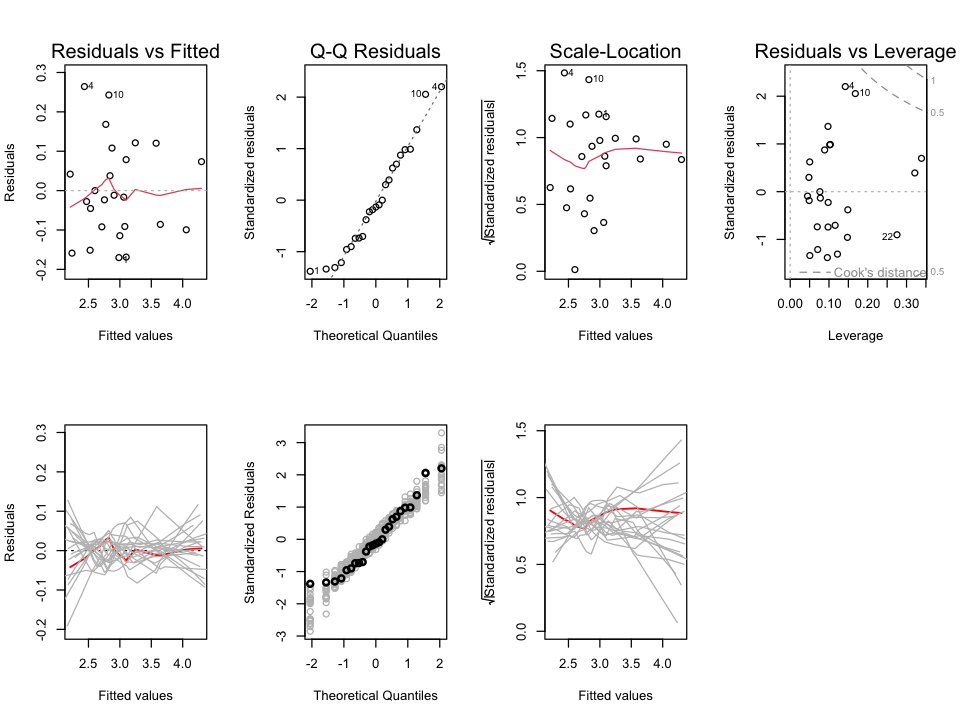

In [51]:
source("advanced-statistical-data-analysis/RFn_Plot-lmSim.R")
df <- read.table("advanced-statistical-data-analysis/Softdrink.dat", header=TRUE)

# Tukey's First-Aid Transformations:
df.tk <- data.frame(
  Time=log(df$Time),
  volume=sqrt(df$volume), # := number of cases of product stocked => count data
  distance=log(df$distance),
  location=df$location) # := categorical variable (text data)

# Linear Regression:
df.tk.lm1 <- lm(Time ~ volume + distance, data=df.tk)

# Residual Analysis:
par(mfrow=c(2,4))
plot(df.tk.lm1)
plot.lmSim(df.tk.lm1, SEED=4711)

- **Tukey-Anscombe Plot:** Residuals vs. Fitted values to check for non-linearity or heteroscedasticity.
- **Normal Q-Q Plot:** To check the normality assumption of errors.
- **Scale-Location Plot:** To check for constant variance.
- **Residuals vs. Leverage:** To identify influential observations (Cook's Distance).

**Model Formulation:**
$$Y_i = \beta_0 + \beta_1 x_i^{(1)} + \beta_2 x_i^{(2)} + \cdots + \beta_m x_i^{(m)} + E_i, \quad i = 1, \ldots, n$$

**Assumptions:**
1. $E_i \sim \mathcal{N}(0, \sigma^2)$ (normally distributed errors)
2. $\mathbb{E}[E_i] = 0$ (zero expectation)
3. $\text{Var}(E_i) = \sigma^2$ (homoscedasticity)
4. $E_i$ are stochastically independent
5. No perfect multicollinearity

**Matrix Notation:**
$$\underline{Y} = \boldsymbol{X} \underline{\beta} + \underline{E}$$

```{math}
:label: eq-linear-model
Y = X\beta + E
```

**Gauss-Markov Theorem:**
Under assumptions 1-4 (without normality), OLS is BLUE (Best Linear Unbiased Estimator).

**Properties:**
- Unbiased: $\mathbb{E}[\hat{\underline{\beta}}] = \underline{\beta}$
- Consistent: $\hat{\underline{\beta}} \xrightarrow{P} \underline{\beta}$
- Asymptotic Normality: $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1})$

# Variable Selection Criteria

## AIC (Akaike Information Criterion)

AIC balances **model accuracy** and **model complexity** to prevent overfitting while maintaining good predictive performance.

```{math}
:label: eq-aic
\mathrm{AIC} = -2 \cdot \text{(maximized log-likelihood)} + 2 \cdot \#\text{estimated parameters}
```

**For linear regression with Gaussian errors:**
```{math}
:label: eq-aic-lm
\mathrm{AIC} = n \log \left\langle \frac{1}{n} \sum_{i=1}^{n} R_{i}^{2} \right\rangle + 2 p^{\diamond} + \text{constant}
```

- **Use case:** Ideal for **prediction** - prefers larger models
- **Implementation:** `step(lm_fit)` in R performs stepwise selection
- **Limitation:** Cannot guarantee finding the global optimum (non-convex criterion)

## BIC (Bayesian Information Criterion)

BIC is similar to AIC but **penalizes complexity more severely**, especially for larger datasets.

```{math}
:label: eq-bic
\mathrm{BIC} = \frac{D}{\phi} - 2 \cdot \ell \left\langle \underline{y}, \phi^{*} \right\rangle + \log(n) \cdot \#\text{estimated parameters}
```

- **Key difference:** Penalty factor is $\log(n)$ instead of 2
- **Use case:** Ideal for **inference/model interpretation** - prefers smaller, more interpretable models
- **Implementation:** `step(lm_fit, k=log(n))` in R
- **Comparison:** For $n > 7$, $\log(n) > 2$, so BIC penalizes more heavily

```{admonition} Important Notes
- AIC and BIC do **not** require nested models for comparison
- Neither method guarantees significant predictors in the final model
- For exhaustive search (guaranteed optimum), use `regsubsets()` from `leaps` package (limited to ~20-25 predictors)
- **Hierarchy principle:** When removing variables:
  - Keep entire factor variables (all dummies) or drop all
  - Cannot remove main effects if interactions are present
  - Cannot remove lower-order polynomial terms if higher-order terms are present
```

# Multicollinearity and VIF

**Multicollinearity** occurs when predictors are **linearly related** (exact or approximate).

- **Exact collinearity:** At least one predictor is a linear combination of others → $\mathbf{X}^T\mathbf{X}$ is **singular** → no unique least squares solution
- **Approximate collinearity:** $\mathbf{X}^T\mathbf{X}$ is **near-singular** → unique but **highly variable** estimates

## Problems Caused

1. **Inflated variance** of coefficient estimates
2. **Unreliable parameter estimates** - signs may be misleading
3. **Difficult interpretation** - cannot isolate individual variable effects
4. **Poor inferential results** - hypothesis tests become unreliable

## Detection Methods

### Correlation Matrix
- Examine pairwise correlations between predictors
- Large values indicate potential multicollinearity

### Regression Approach
- Regress each predictor $x_k$ on all other predictors
- Compute $R_k^2$ for each
- **$R_k^2$ close to 1** indicates a problem

### Variance Inflation Factor (VIF)

VIF quantifies how much the variance of an estimated regression coefficient is inflated due to multicollinearity.

```{math}
:label: eq-var-beta
\operatorname{var} \left\langle \widehat{\beta}_k \right\rangle = \sigma^2 \frac{1}{1 - R_k^2} \frac{1}{\sum_{i=1}^{n} (x_i^{(k)} - \overline{x}_k)^2}
```

```{math}
:label: eq-vif
\mathrm{VIF}_k \coloneqq \frac{1}{1 - R_k^2}
```

**Guideline:** $\mathrm{VIF}_k > 5-10$ indicates **dangerous multicollinearity** that needs addressing.

### Example (R code)
```r
library(car)
model <- lm(mpg ~ ., data=mtcars)
vif(model)
# VIF > 5 or 10 indicates serious multicollinearity
```

### Remedies

1. **Replace correlated variables:** If two variables are highly correlated with same units, use their mean and difference
2. **Create ratios/products:** e.g., Henderson & Velleman's approach: `op <- hp / wt`
3. **Drop variables:** Remove variable with largest VIF, repeat until all VIFs < 5
4. **Use regularization:** Ridge regression or LASSO (not covered in detail here)

# OLS is _not_ robust

Ordinary Least Squares (OLS) is **not robust** to:
- Outliers in the response (y-direction)
- Bad leverage points (x-direction)
- Violations of normality assumption

Real data is **never exactly Gaussian** - robust methods provide reliable fits for the majority of observations.

**Measuring Robustness**

How robust an estimator is, can be investigated by two simple measures:

- influence function and gross error sensitivity:
  The (gross error) sensitivity is based on the influence function and measures the maximum effect of a single observation on the estimated value
- breakdown point:
  returns the minimum proportion of data that can be altered without causing completely unreliable estimates

Hence an estimator with good robustness properties has:

- a bounded gross error sensitivity and
- a breakdown point of (about) 0.5

## Huber's Method

Huber's method uses a **ψ-function** that applies:
- **Quadratic loss** for small residuals (like OLS)
- **Linear loss** for large residuals (down-weights outliers)

This is a **regression M-estimator** that limits the influence of outliers.

```{math}
:label: eq-huber-psi
\psi(r) = \begin{cases}
-r & \text{if } |r| > c \\
-r^2 & \text{if } |r| \leq c
\end{cases}
```

Where $r = \frac{y_i - \underline{x}_i^T\underline{\beta}}{\sigma}$ are **standardized residuals**.

**Recommended kink point:** $c = 1.345$ (based on theoretical efficiency considerations)

The estimator minimizes:
```{math}
:label: eq-huber-objective
\sum_{i=1}^{n} \rho\left(\frac{y_i - \underline{x}_i^T\underline{\beta}}{\sigma}\right)
```

where $\rho$ is the Huber loss function (integral of $\psi$).

## Scale Estimation

The scale parameter $\sigma$ must be estimated **robustly** (standard deviation is not robust):

```{math}
:label: eq-mav
\widehat{\sigma}_{\text{MAV}} := \frac{\operatorname{med}_i \left\langle |r_i| \right\rangle}{0.6745}
```

The correction factor $1/0.6745$ ensures consistency for Gaussian distributions.

## Iteratively Reweighted Least Squares (IRLS) with Huber's $\psi$

Huber's estimator is solved using **Iteratively Reweighted Least Squares (IRLS)**:

1. Start with initial estimates (e.g., OLS)
2. Compute residuals and robust scale estimate
3. Assign weights based on Huber's ψ-function:
   ```{math}
   :label: eq-huber-weights
   w_i = \frac{\psi(r_i)}{r_i} = \begin{cases}
   1 & \text{if } |r_i| \leq c \\
   c/|r_i| & \text{if } |r_i| > c
   \end{cases}
   ```
4. Solve weighted least squares with weights $w_i$
5. Repeat until convergence

**Note:** Because weights depend on residuals (which depend on $\underline{\beta}$), the solution requires iteration.

## RLM (Robust Linear Models)

RLM refers to **robust regression methods** that use **Huber's ψ-function** within an IRLS framework.

**Key characteristics:**
- Uses iteratively reweighted least squares
- Huber's ψ-function for weight calculation
- Robust to outliers and leverage points
- Maintains high efficiency for clean data

**Implementation in R:**
```r
library(MASS)
rlm_model <- rlm(y ~ x1 + x2, data=mydata, method="MM")
# or
library(robustbase)
robust_model <- lmrob(y ~ x1 + x2, data=mydata)
```

## MM-Estimator

To handle **bad leverage points**, use **redescending ψ-functions** (e.g., Tukey's bisquare):

```{math}
:label: eq-tukey-psi
\psi(r) = r \cdot \left[1 - \left(\frac{r}{b}\right)^2\right]^2 \cdot I(|r| < b)
```

- **Breakdown point:** 50% (can handle up to 50% outliers)
- **Challenge:** Many local optima
- **Solution:** MM-estimator uses S-estimator for initial values, then refines with redescending M-estimator

## Robust Regression: From OLS to MM-estimator

| Estimator                           |Purpose|Problem Addressed|Weights|
|:------------------------------------|:--|:--|:--|
| OLS (Ordinary Least Squares)        |Standard regression|None (assumes ideal conditions)|All weights = 1|
| WLS (Weighted Least Squares)        |Efficiency improvement|Heteroscedasticity (non-constant variance)|Known from variance structure|
| M-estimator (Max Likelihood)        |Robustness|Outliers in response|Data-driven from residuals|
| S-estimator (Scale, $\sigma$)       |Robust scale|Outliers + leverage points|Implicit in scale estimation|
| MM-estimator (Modified M-estimator) |Best of both|Outliers + leverage + efficiency|Two-step: S then M|

We need S-estimators, M-estimators, and MM-estimators because real-world data often violates the assumptions of OLS regression. Therefore, we need robust estimators:

1. OLS has 0% breakdown point - even one bad data point can ruin your analysis
2. M-estimators alone can't handle leverage points - outliers in predictors are still problematic
3. S-estimators are too computationally expensive for routine use
4. MM-estimators give us the best of both worlds - robustness AND practicality

Use MM-estimators as your default robust regression method. They provide protection against both outliers and leverage points while maintaining good statistical efficiency.

In [52]:
options(repr.plot.width = 8, repr.plot.height = 6)

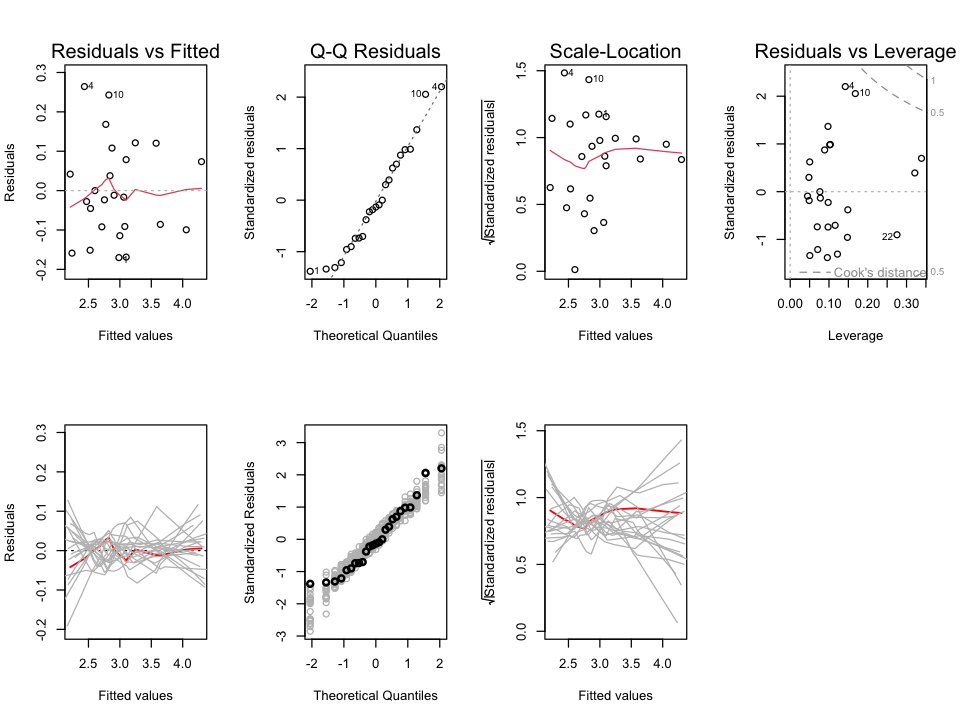

In [53]:
library(robustbase)
source("advanced-statistical-data-analysis/RFn_Plot-lmSim.R")
df <- read.table("advanced-statistical-data-analysis/Synthetic.dat", header=TRUE)

# Robust fit:
df.rlm <- lmrob(Y ~ x1 + x2, data=df, method="MM")

# Residual Analysis:
par(mfrow=c(2,4))
plot(df.tk.lm1)
plot.lmSim(df.tk.lm1, SEED=4711)

# Smooth Function Fitting

## LOESS (Locally Weighted Scatterplot Smoothing)

LOESS fits **local parametric regressions** (typically linear or quadratic) within moving windows.

**Algorithm:**
1. Choose a window with width $2b_w$ around point $x$
2. Fit a straight line (or curve) to data within the window using **weighted regression**
3. Predicted value at window center = smoother value
4. Repeat for a set of x-values
5. Connect points to visualize the smoother

**Key parameters:**
- **span:** Fraction of total points used for each neighborhood (default: 2/3)
- **degree:** Degree of local polynomial (0=constant, 1=linear, 2=quadratic)
- **family:** Weighting function (symmetric, Gaussian)

**Properties:**
- Non-parametric - no global functional form assumed
- Flexible - can capture complex relationships
- Computationally intensive
- Sensitive to span parameter (too small → noisy, too large → oversmoothed)

**R implementation:**
```r
# Basic LOESS
loess_fit <- loess(y ~ x, data=mydata, span=2/3, degree=1)

# LOESS smoothing for visualization
h.smooth <- loess.smooth(x, y, family="symmetric")
lines(h.smooth, col="red")

# With GAM
library(mgcv)
gam_fit <- gam(y ~ lo(x), data=mydata)
```

## Splines

Splines represent smooth functions as **linear combinations of basis functions**.

### Basis Function Representation
```{math}
:label: eq-spline-basis
f\left\langle x \right\rangle = \sum_{m=1}^{M} \gamma_m h_m\left\langle x \right\rangle
```

- $h_m\left\langle \cdot \right\rangle$ are known basis functions
- $\gamma_m$ are unknown coefficients estimated from data (typically by OLS)
- $M$ controls smoothness and complexity

### Types of Splines

1. **Natural Cubic Splines**
   - Piecewise cubic polynomials
   - Natural boundary conditions: linear beyond boundary knots
   - Continuous first and second derivatives
   - Knots at data points or specified locations

2. **B-splines (Basis splines)**
   - Local support - each basis function non-zero only on a limited interval
   - More numerically stable
   - Can control smoothness via knot placement

3. **Thin Plate Splines**
   - Radial basis functions
   - Minimize bending energy
   - Used in 2D and higher dimensions

### Penalized Splines (P-splines)

To prevent **overfitting**, minimize:
```{math}
:label: eq-penalized-spline
\sum_{i=1}^{n} \left(y_i - f\left\langle x_i \right\rangle\right)^2 + \lambda \cdot \text{“roughness”}
```

- **Left term:** Goodness-of-fit (sum of squared residuals)
- **Right term:** Penalty for complexity/roughness
- **λ:** Smoothing parameter controlling trade-off
- **Roughness:** Typically measured by integrated squared second derivative

**Key result:** For any $\lambda > 0$, the solution is a **cubic spline** with knots at each data point, but with **shrunken coefficients**.

**Choosing λ:** Use **leave-one-out cross-validation** (or PRESS statistic)

**R implementation:**
```r
library(splines)
# Natural cubic spline
ns_fit <- lm(y ~ ns(x, df=5), data=mydata)

# B-spline
bs_fit <- lm(y ~ bs(x, df=5), data=mydata)

# With GAM (automatic smoothness selection)
library(mgcv)
gam_fit <- gam(y ~ s(x), data=mydata)
```


# Additive Models

## Generalized Additive Models (GAM)

GAMs extend linear models by allowing **non-linear smooth functions** for predictors.

**Model structure:**
```{math}
:label: eq-gam
Y_i = \beta_0 + f_1\left\langle x_i^{(1)}\right\rangle + f_2\left\langle x_i^{(2)}\right\rangle + \cdots + f_m\left\langle x_i^{(m)}\right\rangle + E_i
```

- $E_i \sim \mathcal{N}(0, \sigma^2)$ (for Gaussian GAM)
- Each $f_j\left\langle \cdot \right\rangle$ is a **smooth function** (e.g., spline, LOESS)
- Functions can be **non-parametric transformations** of predictors

**Key features:**
- Additive structure - each predictor contributes independently
- Flexible - can model complex non-linear relationships
- Interpretable - can visualize each smooth function
- Automatic smoothness selection available

**R implementations:**

1. **mgcv package** (recommended):
   ```r
   library(mgcv)
   gam_fit <- gam(y ~ s(x1) + s(x2) + s(x3), data=mydata)
   summary(gam_fit)
   plot(gam_fit, se=TRUE)  # Visualize smooth functions
   ```
   - Uses **penalized splines** by default
   - **Automatic** smoothness parameter selection
   - Efficient computation

2. **gam package:**
   ```r
   library(gam)
   gam_fit <- gam(y ~ lo(x1) + lo(x2), data=mydata)
   ```
   - Uses **LOESS** or **smoothing splines**
   - **Manual** smoothness selection required
   - Uses backfitting algorithm

**Model formula:**
- `s(x)` - smooth function of x (thin plate spline in mgcv)
- `lo(x)` - LOESS smoother
- `ns(x, df=k)` - natural cubic spline with k degrees of freedom
- `bs(x, df=k)` - B-spline with k degrees of freedom

## Example: Canadian Prestige Data

```r
library(car)
data(Prestige)
P <- Prestige

# Fit GAM with LOESS smoothers
library(gam)
P.gam <- gam(prestige ~ lo(income) + lo(education), data=P)

# Visualize
par(mfrow=c(2,2))
plot(P.gam, se=TRUE)  # Shows partial effects

# Summary
summary(P.gam)
```

**Interpretation:**
- Each plot shows the relationship between a predictor and response, **with other predictors held constant**
- The smooth curve represents the estimated function $f_j\left\langle \cdot \right\rangle$
- Shaded region shows confidence intervals

# Logistic Regression (Binary Regression)

## Theoretical Background

**Logistic Regression Model:**
$$P(Y_i = 1 | \underline{X}_i) = \pi_i = \frac{1}{1 + e^{-\eta_i}}, \quad \eta_i = \underline{X}_i^T \underline{\beta}$$

**Logit Link:**
$$\log\left\langle \frac{\pi_i}{1 - \pi_i} \right\rangle = \eta_i$$

**Odds Ratio:**
$$\text{OR} = e^{\beta_j} = \frac{\text{Odds}(Y=1 | X_j = x+1)}{\text{Odds}(Y=1 | X_j = x)}$$

**Asymptotic Properties:**
- $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \mathcal{I}^{-1})$
- Wald tests valid for large samples

In [54]:
options(repr.plot.width = 3, repr.plot.height = 3)

(Intercept)         Hours 
-3.9235965551  0.0009992372

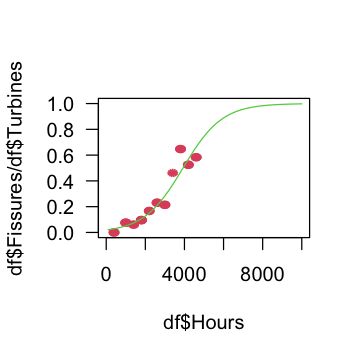

In [55]:
df <- read.table("advanced-statistical-data-analysis/turbines.dat", header = TRUE)

# glm format: glm(x ~ y, family=…, data=…)
df.glm <- glm(cbind(Fissures, Turbines-Fissures) ~ Hours, family=binomial, data=df)
coef(df.glm)

df.p <- data.frame(Hours=seq(100, 10000, by=100))
df.y <- predict(df.glm, newdata=df.p, type="response")
sunflowerplot(x=df$Hours, y=df$Fissures/df$Turbines, las=1, number=df$Turbines, xlim=c(0, 10000), ylim=c(0,1))
lines(df.p$Hours, df.y, col=3)

# Generalized Linear Models (GLM) - A Unifying Model Family

## Exponential Family

$$f(y_i; \mu_i, \phi) = \exp \left\langle \frac{y_i b(\mu_i) - c(\mu_i)}{\phi} w_i + d(y_i; \phi, w_i) \right\rangle$$

- The dispersion parameter $\phi$ is connected to the variance
- The value $w_i$ is a fixed known number (weighting)
- The function $d(y_i; \phi, w_i)$ scales the probability to 1.
- The functions $b(\mu_i)$ and $c(\mu_i)$ determine the distribution.

**Expected Value:**
$$\mu_i = \mathbb{E}[Y_i] = \frac{c'(\mu_i)}{b'(\mu_i)}$$

where $b'(\mu)$ and $c'(\mu)$ are the first derivatives with respect to $\mu$.

**Variance:**
$$\text{Var}(Y_i) = \frac{\phi}{w_i} V(\mu_i), \quad V(\mu_i) = \frac{1}{b'(\mu_i)}$$

#### Common Distributions

| Distribution                             | Range of $Y$ | $\mathbb{E}\langle Y\rangle = \mu$ | $\text{var}\langle Y\rangle$ | $b\langle \mu\rangle$ | $V\langle \mu\rangle$ | $\phi$ | $w$ |
|------------------------------------------|---------------|--------------------------------|-----------------------------|------------------|------------------|--------|------|
| Gaussian $\langle \mu, \sigma^2 \rangle$ | $(-\infty, +\infty)$ | $\mu$ | $\sigma^2$ | $\mu$ | $1$ | $\sigma^2$ | $1$ |
| Binomial $\langle m, \pi \rangle$        | $\{0,1,2,\ldots,m\}$ | $\pi$ | $\frac{\pi(1-\pi)}{m}$ | $\log\left\langle \frac{\mu}{1-\mu} \right\rangle$ | $\mu(1-\mu)$ | $1$ | $m$ |
| Poisson $\langle \lambda \rangle$        | $\{0,1,2,\ldots\}$ | $\lambda$ | $\lambda$ | $\log\langle \mu \rangle$ | $\mu$ | $1$ | $1$ |
| Gamma $\langle \alpha, \beta \rangle$    | $(0, \infty)$ | $\frac{\alpha}{\beta}$ | $\frac{\alpha}{\beta^2}$ | $-\frac{1}{\mu}$ | $\mu^2$ | $\frac{1}{\alpha}$ | $1$ |
| Inverse Gaussian                         | $(0, \infty)$ | $\mu$ | $\frac{\mu^3}{\lambda}$ | $-\frac{1}{\mu^2}$ | $\mu^3$ | $\frac{1}{\lambda}$ | $1$ |

- **Distribution:** The probability distribution of the response variable $Y$;Defines the random component of the GLM
- **Range of $Y$:** The support (set of possible values) for the response variable; Determines which distribution is appropriate for your data
- **$\mathbb{E}\langle Y\rangle = \mu$:** The expected value (mean) of the response; The target of your regression model
- **$\text{var}\langle Y\rangle$:** The variance of the response variable; Determines precision of estimates
- **$b\langle \mu\rangle$:** The canonical link function from the exponential family density; $\eta = b'(\mu)$
- **$V\langle \mu\rangle$:** The variance function; Connects mean to variance: $var(Y) = \frac{\phi}{w} V(\mu)$
- **$\phi$:** The dispersion parameter; Scales the variance: larger $\phi$ means more spread
- **$w$:** The prior weight for each observation; Known constant for each observation (e.g., $m$ for binomial)

::::{grid} 2 2

:::{card}
:header: Normal/Gaussian: $\mathcal{N}(\mu, \sigma^2)$
- $\mathbb{E}[Y] = \mu$
- $Var(Y) = \sigma^2$

```r
glm(y ~ x1 + x2, family = gaussian)
# or simply: lm(y ~ x1 + x2)
```
:::

:::{card}
:header: $\text{Binomial}(m, \pi)$
- $\mathbb{E}[Y] = m\pi$
- $Var(Y) = m\pi(1-\pi)$

```r
# Binary data
glm(y ~ x1 + x2, family = binomial)

# Aggregated data (successes and failures)
glm(cbind(success, failure) ~ x1 + x2, family = binomial)
```
:::

:::{card}
:header: $\text{Poisson}(\lambda)$
- $\mathbb{E}[Y] = \lambda$
- $Var(Y) = \lambda$

```r
glm(y ~ x1 + x2, family = poisson)
```
:::

:::{card}
:header: $\text{Gamma}(\alpha, \beta)$
- $\mathbb{E}[Y] = \alpha/\beta$
- $Var(Y) = \alpha/\beta^2$

```r
glm(y ~ x1 + x2, family = Gamma)
```
:::

:::{card}
:header: Inverse Gaussian: $IG(\mu, \lambda)$
- $\mathbb{E}[Y] = \mu$
- $Var(Y) = \mu^3 / \lambda$

```r
glm(y ~ x1 + x2, family = inverse.gaussian)
```
:::
::::

## Distribution Decision Tree

- **Check variance**: For Poisson, verify mean ≈ variance. If variance > mean, consider **Negative Binomial** (not in exponential family)
- **Check range**: Ensure response values are valid for the distribution (e.g., Poisson requires y ≥ 0)
- **Check skewness**: Right-skewed data may need Gamma or Inverse Gaussian
- **Check zeros**: Excess zeros may require zero-inflated models

```{mermaid}
graph TD
    A[Response Type] --> B{Continuous?}
    B -->|Yes| C{Range?}
    B -->|No| D{Count or Binary?}
    C -->|-∞, +∞| E[Gaussian]
    C -->|0, +∞| F{Skewed?}
    F -->|No| E
    F -->|Yes| G[Gamma or Inverse Gaussian]
    D -->|Binary/Proportion| H[Binomial]
    D -->|Count 0,1,2...| I[Poisson]
```

## GLM Structure

The **Generalized Linear Model (GLM)** is defined by **two fundamental elements**:

1. **Distributional Element** \
  The distribution of the response $Y_i$, given the explanatory variables $\underline{x}_i$, belongs to the _two-parameter exponential family_ with:
  - _Expectation:_ $\mathbb{E}\langle Y_i \mid \underline{x}_i \rangle = \mu_i$
  - _Dispersion:_ $\phi$
  The responses $Y_i$, $i = 1, \ldots, n$, are _independently distributed_.
2. **Structural Element** \
  The expectation $\mu_i$ is related to the _linear predictor_ $\eta_i = \underline{x}_i^T \underline{\beta}$ of the explanatory variables by applying a (possibly nonlinear) function $g\left\langle \cdot \right\rangle$ on $\mu_i$:
  $$
  g\left\langle \mu_i \right\rangle = \eta_i = \underline{x}_i^T \underline{\beta}.
  $$
  The function $g\left\langle \cdot \right\rangle$ is called the _link function_.

The estimator for $\underline{\beta}$ is derived based on the **maximum likelihood principle**:

- It is defined by a **nonlinear system of equations**
- It can be solved most efficiently by the **IRLS algorithm**

This two-element structure (distributional + structural) is what unifies various regression models (linear, logistic, Poisson, etc.) under the GLM framework.

## IRLS Algorithm for GLM Fitting

The **Iteratively Reweighted Least Squares (IRLS)** algorithm fits Generalized Linear Models through the following iterative steps:

1. **Initialize** \
   Put $\hat{\mu}_i = Y_i$

2. **Ensure Valid Weights** \
   If necessary, modify $\hat{\mu}_i$ so that the weights $\tilde{w}_i$ below are non-zero (e.g., as done by the empirical logits)

3. **Calculate Weights**
   $$
   \tilde{w}_i \coloneqq \frac{w_i}{V\left\langle \hat{\mu}_i \right\rangle \left( g'\left\langle \hat{\mu}_i \right\rangle \right)^2}
   $$

4. **Form Adjusted Response**
   $$
   z_i \coloneqq \underline{x}_i^T \hat{\underline{\beta}} + \left( Y_i - \hat{\mu}_i \right) g'\left\langle \hat{\mu}_i \right\rangle
   $$

5. **Weighted Least Squares** \
   Regress $\sqrt{\tilde{w}_i}  z_i$ on $\sqrt{\tilde{w}_i}  \underline{x}_i$ by least squares to obtain $\hat{\underline{\beta}}$. That is, solve the system of linear equations:
   $$
   \sum_{i=1}^n \tilde{w}_i \left( z_i - \underline{x}_i^T \hat{\underline{\beta}} \right) \underline{x}_i = \underline{0} \quad \text{for } \hat{\underline{\beta}}.
   $$

6. **Update Fitted Values** \
   Calculate the fitted values:
   $$
   \hat{\mu}_i = g^{-1}\left\langle \underline{x}_i^T \hat{\underline{\beta}} \right\rangle
   $$

7. **Iterate** \
   Return to step 2 and iterate until convergence

**The dispersion parameter $\phi$ must be estimated as well:**

- It can also be done by maximizing the likelihood.
- As we know from multiple linear regression, we rather use an unbiased estimator for estimating the dispersion parameter $\phi = \sigma^2$
- In the case of binomial and Poisson distribution: $\phi = 1$
- For other distributions: see table above

# Causality

```{warning}
Association does not imply causation.
```

**The Ladder of Causation (Pearl):**
1. **Association (Seeing):** Observing patterns
2. **Intervention (Doing):** Estimating effects of actions
3. **Counterfactuals (Imagining):** Reasoning about hypotheticals

**Notation:**
- $P(Y | X = x)$: Conditional probability
- $P(Y | \text{do}(X = x))$: Causal effect

**Causal Graphical Models:**
- **Nodes:** Variables
- **Edges:** Causal relationships
- **DAG:** Directed Acyclic Graph (no cycles)

**Graphical Structures:**
1. **Chain:** $X → Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
2. **Fork:** $X ← Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
3. **Collider:** $X → Z ← Y$
  - $X$ and $Y$ are **independent** $(X \perp\!\!\!\perp Y)$, but are **conditionally dependent** on Z and any descendants of Z; $(X \not\perp\!\!\!\perp Y \mid Z)$

```{math}
:label: def-dseparation
X \perp\!\!\!\perp Y \mid Z \text{ if all paths between X and Y are blocked by Z}
```

## Intervention changes distribution

![Intervention changes distribution 1](advanced-statistical-data-analysis/Intervention-changes-distribution-1.png)

![Intervention changes distribution 2](advanced-statistical-data-analysis/Intervention-changes-distribution-2.png)

#### Key R Code Snippets

In [26]:
library(gRbase)
g <- dag(
  c("A"),
  c("B", "A", "E"), # = root node + all incoming node-edges
  c("C", "A", "B", "D"),
  c("D", "B"),
  c("E")
)

cat("Children of B = ", children("B", g), "\n")
cat("Parents of B = ", parents("B", g), "\n")
cat("Ancestors of B = ", ancestralSet("B", g), "\n")

Children of B =  C D 
Parents of B =  A E 
Ancestors of B =  A B E 


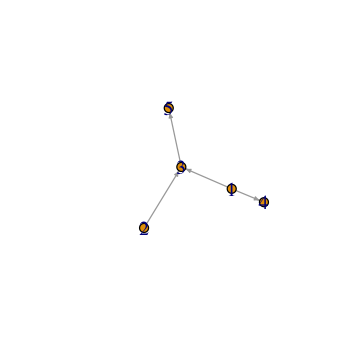

In [56]:
options(repr.plot.width = 3, repr.plot.height = 3)
plot(g)

In [28]:
m <- as(g, "matrix") # to matrix from graph
m
g1 <- as(m, "igraph") # to igraph from matrix

,A,B,E,C,D
A,0,1,0,1,0
B,0,0,0,1,1
E,0,1,0,0,0
C,0,0,0,0,0
D,0,0,0,1,0


In [57]:
options(repr.plot.width = 3, repr.plot.height = 3)

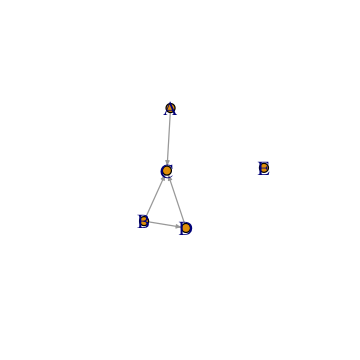

In [58]:
# Intervention on B (i.e. remove edges):
g2 <- removeEdge("A", "B", removeEdge("E", "B", g1))
plot(g2)

## Simpson's Paradox & Graphical Models

**Simpson's Paradox:**
A trend appears in different groups but disappears or reverses when combined.

**Factorization:**
- **Chain:** $P(X,Z,Y) = P(X)P(Z|X)P(Y|Z)$
- **Fork:** $P(X,Z,Y) = P(Z)P(X|Z)P(Y|Z)$
- **Collider:** $P(X,Z,Y) = P(X)P(Y)P(Z|X,Y)$

**Bayesian Network Factorization:**
$$P(X_1, \ldots, X_n) = \prod_{i=1}^n P(X_i | \text{Parents}(X_i))$$

#### Key R Code Snippets

In [30]:
library(gRbase)
library(gRain)

graph.toys <- dag(c("Gender"), c("Toy","Gender"))
load("advanced-statistical-data-analysis/toys.rda")
gn <- grain(graph.toys, data = toys) # combine graph and data to a Bayesian network

In [31]:
# Conditional probability: from data
toys_girls <- toys[toys$Gender== "girl",]
cat("P(Toy = car | Gender = girl) =", sum(toys_girls== "car") / nrow(toys_girls))

# Conditional probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="conditional")

P(Toy = car | Gender = girl) = 0.3915344

,boy,girl
car,0.8931624,0.3915344
doll,0.1068376,0.6084656


In [32]:
# Joint probability: from data
n_car_girl <- sum(toys$Toy== "car" & toys$Gender== "girl")
cat("P(Toy = car, Gender = girl) =", n_car_girl/nrow(toys))

# Joint probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="joint")

P(Toy = car, Gender = girl) = 0.1749409

,car,doll
boy,0.4940898,0.05910165
girl,0.1749409,0.27186761


In [33]:
# marginal probabilities
querygrain(gn, nodes = "Gender", type = "marginal")
querygrain(gn, nodes = "Toy", type = "marginal")

$Gender
Gender
      boy      girl 
0.5531915 0.4468085

$Toy
Toy
      car      doll 
0.6690307 0.3309693

In [59]:
options(repr.plot.width = 3, repr.plot.height = 3)

,boy,girl
car,0.8989899,0.3939394
doll,0.1010101,0.6060606


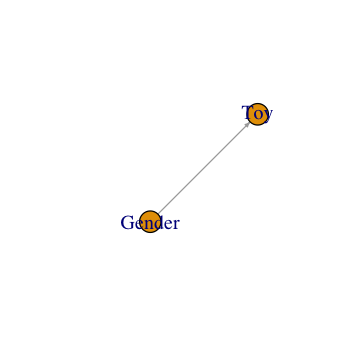

In [60]:
# Manually using a Conditional Probability Table:
gender <- cptable("Gender", values = c(0.55, 0.45), levels = c("boy","girl"))
toy <- cptable("Toy", values = c(0.67, 0.33), levels = c("car","doll"))

toy_gender <- cptable(c("Toy", "Gender"),
  # car:boy = 0.89, doll:boy = 0.10, car:girl = 0.39, doll:girl = 0.60
  values = c(0.89, 0.10, 0.39, 0.60), levels = c("car","doll"))

# Building the Bayesian Network
cpt <- compileCPT(list(gender, toy_gender))
bn <- grain(cpt, compile = FALSE)
plot(bn)

querygrain(bn, nodes=c("Toy", "Gender"), type="conditional")

## D-Separation & Causal Effect Estimation

**D-Separation:**

X and Y are d-separated given Z if all paths between X and Y are blocked by Z if and only if:

1. a middle node of a chain (X → B → Y) or a fork (X ← B → Y) is conditioned on (i.e. it is in Z)
2. a middle node of a collider (X → B ← Y) is **_not_** conditioned on (i.e. is _not_ in Z), and no descendant of B is in Z.

If Z blocks every path between two nodes X and Y, then X and Y are d-separated conditioning on Z and thus are conditionally independent on Z.

**Adjustment Formula:**
$$P(Y | \text{do}(X = x)) = \sum_z P(Y | X = x, Z = z) P(Z = z)$$

:::{prf:definition} Average Causal Effect
$$
ACE(a,b) = P(Y | do(X = a)) - P(Y | do(X = b))
$$
:::

**Backdoor Criterion:**
Z satisfies backdoor criterion if:
1. Z blocks all backdoor paths from X to Y
2. Z does not contain any descendants of X

:::{attention} From Backdoor Criterion to D-Separation
The backdoor criterion is related to d-Separation as follows: \
If a set $Z$ satisfies the backdoor criterion relative to $X$ and $Y$, then
$X$ and $Y$ are d-separated by $Z$ in the manipulated causal graph, which is
the causal graph obtained by **removing all arrows starting from $X$**.
:::

In [61]:
options(repr.plot.width = 3, repr.plot.height = 3)

Are E and D d-separated by Z = {B}? TRUE 
Are E and C d-separated by Z = {A}? FALSE 
Are A and D d-separated by Z = {B, C}? FALSE 


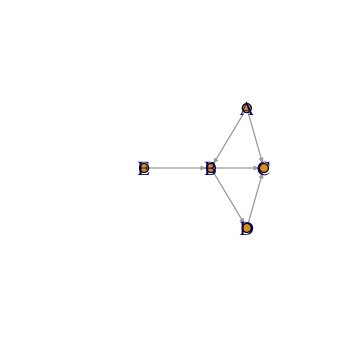

In [62]:
library(gRbase)
# List all nodes with their parents
g <- dag("A",c("B","A","E"),c("C","A","B","D"),c("D","B"),c("E"))
d.separates <- function(a,b,c,dag){
    separates(a,b,c, moralize(ancestralGraph(union(union(a,b),c),dag)))
}
plot(g)
cat("Are E and D d-separated by Z = {B}?", d.separates("E", "D", c("B"), g), "\n")
cat("Are E and C d-separated by Z = {A}?", d.separates("E", "C", c("A"), g), "\n")
cat("Are A and D d-separated by Z = {B, C}?", d.separates("A", "D", c("B", "C"), g), "\n")

## Structural Causal Models

**Linear SCM:**
$$\begin{aligned}
X &= f_X(E_X) \\
W &= 5X + 10Z + E_W \\
Y &= 12W + E_Y
\end{aligned}$$

**Direct vs. Total Effects:**
- **Total:** Effect through all paths
- **Direct:** Effect through direct path only

#### Key R Code Snippets

In [63]:
options(repr.plot.width = 3, repr.plot.height = 3)

Warning message:
“Non-positive edge weight found, ignoring all weights during graph layout.”


attendance 
 -24.00246

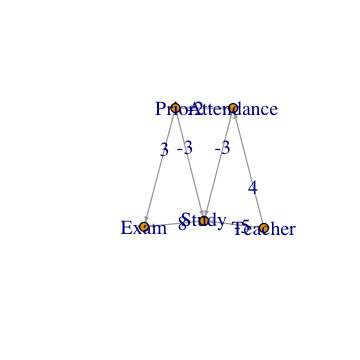

In [64]:
library(gRbase)
library(igraph)

set.seed(253)

g <- dag(
  c("Study", "Teacher", "Prior", "Attendance"),
  c("Attendance", "Prior", "Teacher"),
  c("Exam", "Study", "Prior")
)
E(g)$weight <- c(-5, -3, -3, -2, 4, 8, 3)
plot(g, edge.label = E(g)$weight)

n <- 1000000  # Sample size

# Simulate data from the SCM (using the DAG's coefficients)
prior      <- rnorm(n)
teacher    <- rnorm(n)
attendance <- -2 * prior + 4 * teacher + rnorm(n)
study      <- -3 * prior - 5 * teacher + -3 * attendance + rnorm(n)
exam       <- 3 * prior + 8 * study + rnorm(n)

# Estimate total causal effect of attendance on exam
fit <- lm(exam ~ attendance + prior + teacher)
coef(fit)["attendance"]  # Returns the estimated effect (-24 for large n)

## Advanced Topics

**Instrumental Variables:**
1. **Relevance:** $\text{Cov}(Z, X) \neq 0$
2. **Exclusion:** Z has no direct effect on Y except through X
3. **Exogeneity:** $\text{Cov}(Z, E) = 0$

**Two-Stage Least Squares:**
1. First stage: $X = \pi_0 + \pi_1 Z + U$
2. Second stage: $Y = \beta_0 + \beta_1 \hat{X} + E$

**Counterfactuals:**
Pearl's three-step method:
1. **Abduction:** Use the observed information to determine the values of the noise variables.
2. **Action:** Modify the causal model M by removing the structural equation for the variable X and replacing with X = x.
3. **Prediction:** Use the modified  model $M_x$ to compute the counterfactual.

In [65]:
options(repr.plot.width = 3, repr.plot.height = 3)


Call:
lm(formula = Adv ~ Temp, data = ice_cream)

Coefficients:
(Intercept)         Temp  
     110.94         1.74  


Call:
lm(formula = Sales ~ Temp + Adv, data = ice_cream)

Coefficients:
(Intercept)         Temp          Adv  
   -258.252       22.293        2.032  



,Temp,Adv,Sales
,<dbl>,<dbl>,<dbl>
19,34.1,174.4516,885


if the temperature would have been 30 then 779.1024 ice creams would have been sold 
without advertisement on that day, 530.5143 ice creams would have been sold 
Average number of ice creams sold for days with given temperature and advertisement:  764.971 501.93 


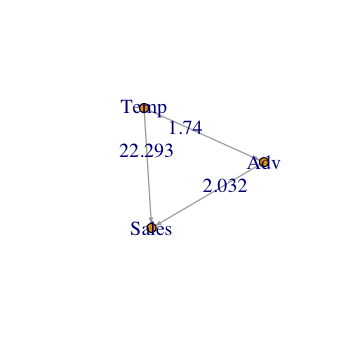

In [66]:
library(gRain)

g <- dag(
  c("Temp"),
  c("Adv", "Temp"),
  c("Sales", "Temp", "Adv")
)

load("advanced-statistical-data-analysis/ice_cream.rda")
lm.adv <- lm(Adv ~ Temp, data = ice_cream)
lm.sales <- lm(Sales ~ Temp + Adv, data = ice_cream)
print(lm.adv)
print(lm.sales)

E(g)$weight <- c(1.74, 22.293, 2.032)
plot(g, edge.label = E(g)$weight)

# look at the observation with the highest daily temperature:
ice_cream[ice_cream$Temp == max(ice_cream$Temp), ]
day19 <- ice_cream[19,]

# Counterfactuals:

# 1. Abduction:
Es <- day19$Sales - (22.293 * day19$Temp + 2.032 * day19$Adv)
Ea <- day19$Adv - (1.74 * day19$Temp)
Et <- day19$Temp

# how many ice creams would have been sold on that day, if
# temperature would have been 30? -> do(Temp = 30):

# 2. Action:
temp_c1 <- 30
adv_c1 <- 1.74 * temp_c1 + Ea

# 3. Prediction:
sales_c1 <- 22.293 * temp_c1 + 2.032 * adv_c1 + Es
cat("if the temperature would have been", temp_c1, "then", sales_c1, "ice creams would have been sold", "\n")

# do(Adv = 0):
# how many ice creams would have been sold on that day, if
# there would have been no advertisement? -> do(Adv = 0):

# 2. Action:
temp_c2 <- day19$Temp
adv_c2 <- 0

# 3. Prediction:
sales_c2 <- 22.293 * temp_c2 + 2.032 * adv_c2 + Es
cat("without advertisement on that day,", sales_c2, "ice creams would have been sold", "\n")

# Use linear regression to predict the average number of ice creams sold for the counterfactuals
x0 <- data.frame(
  Temp = c(30, day19$Temp),
  Adv  = c(day19$Adv, 0))
cat("Average number of ice creams sold for days with given temperature and advertisement: ", predict(lm.sales, newdata = x0), "\n")

# The prediction describes the average number of ice creams. In contrast,
# the counterfactual describes how many ice creams would have been sold on the
# specific day (corresponding to data point 19) if the temperature
# and advertising had been different.

## Markov Equivalence

- Chains and Forks are Markov equivalent, i.e. their graphs imply the  same conditional independencies.
- Colliders encode a different independence.

→ Colliders are identifiable from data, whereas fork and chains are not \
→ All graphs where we can flip the arrows without introducing new colliders and keeping all existing colliders are Markow Equivalent.

Markov Equivalence can be represented by a CPDAG.

**Completed Partially DAG (CPDAG)**

represents the Markov equivalence class of DAGs

- Directed edge: causal direction is clear (all graphs agree)
- Undirected edge: causal direction is ambiguous (graphs disagree)
- Encodes what can be identified from data alone

![CPDAG](advanced-statistical-data-analysis/CPDAG.png)

#### Key R Code Snippets

```{code-block} R
---
name: instrumental-variables
---
library(AER)
model_iv <- ivreg(Y ~ X + W | Z + W, data = mydata)
summary(model_iv)
first_stage <- lm(X ~ Z + W, data = mydata)
summary(first_stage)
```

```{code-block} R
---
name: markov-equivalence
---
library(pcalg)
dag1 <- dag(c("X", "Z", "Y"), list(c("X", "Z"), c("Z", "Y")))
dag2 <- dag(c("X", "Z", "Y"), list(c("Z", "X"), c("Z", "Y")))
meq(dag1, dag2)
```

## Causal Structure Learning

**Assumptions of Independence-Based Methods:**

- _Causal sufficiency_, i.e., no unobserved confounding variables.
- _Acyclicity_: No directed cycles in the graph
- _Markov_: Graph → Data, i.e., if X and Y are d-separated by Z in the graph,  then X and Y are conditionally independent given Z.
- _Faithfulness_: Data → Graph, i.e., if X and Y are conditionally independent  given Z, then X and Y are d-separated by Z in the graph.

:::{prf:algorithm} Peter-Clark (PC) Algorithm
Assuming causal sufficiency, acyclicity, Markov and faithfulness, a CPDAG can be estimated by the PC algorithm:

Input: Information about conditional independence

1. Start with a fully connected undirected graph
2. Identify the skeleton by removing edges
3. Identify colliders and orient them
4. Apply orientation rules making use of colliders and acyclicity.

Output: CPDAG

Remarks:
- Be careful when choosing $\alpha$ due to multiple testing.
- PC algorithm relies on accurate conditional independence testing
- **It’s quite hard to get accurate test results if there is not enough data.**
:::

:::{prf:theorem}
The causal graph of a SCM with Gaussian noise can only be identified up to its Markov equivalence class.
:::

$\to$ What about non-Gaussian structural equations? LinGAM to the rescue!

:::{prf:algorithm} Linear Non-Gaussian Acyclic Models (LiNGAM) Algorithm
- Assumes linear relationships with non-Gaussian errors
- Uses Independent Component Analysis (ICA) to identify causal order
- Can identify full causal graph

Input: Data matrix X

1. Apply ICA on the X to obtain $\hat{E}$ and $W = \hat{A}^{−1}$.
2. Find a permutation of rows of W that yield a matrix $\tilde{W}$̃ without zeros on diagonal and scale $\tilde{W}$̃ row-wise by its diagonal elements.
3. Compute $\hat{B} = I - \tilde{W}$.
4. Permute $\hat{B}$ until it is strictly lower triangular by also testing edges weights for significance and prune if reasonable.

Output: matrix $B$, i.e. estimated SCM
:::

## 4 Steps of Causal Inference

1. **DAG:** Create a causal model using expert knowledge.
2. **Identification:** Determine whether and how the causal effect can be identified from the observational data.
3. **Estimation:** Estimate the causal effect from the data.
4. **Validity:** Test the estimated causal effect:

| **Method**   | **Idea**                     | **Good if ...**       |
|--------------|------------------------------|-----------------------|
| Random Cause | Add random covariate         | Estimate stable       |
| Placebo      | Randomize treatment X        | Estimate $\approx 0$ |
| Data Subset  | cross-validation / bootstrap | Estimates similar     |

#### Key R Code Snippets

In [71]:
options(repr.plot.width = 3, repr.plot.height = 3)

Object of class 'pcAlgo', from Call:
pc(suffStat = suffStat, indepTest = gaussCItest, alpha = 0.01, 
    labels = colnames(dat), verbose = FALSE)

Nmb. edgetests during skeleton estimation:
Max. order of algorithm:  3 
Number of edgetests from m = 0 up to m = 3 :  19 29 12 4

Graphical properties of skeleton:
Max. number of neighbours:  2 at node(s) 3 
Avg. number of neighbours:  0.8 

Adjacency Matrix G:
  X Z W Y V
X . . 1 . .
Z . . 1 . .
W . . . 1 1
Y . . . . .
V . . . . .


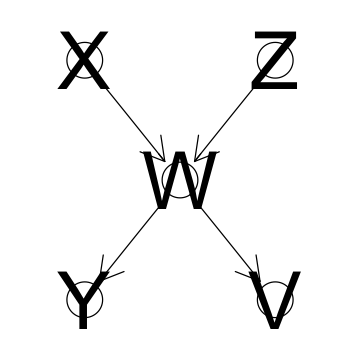

In [72]:
# PC Algorithm:
library(pcalg)

# Example data generation
set.seed(239)
N <- 500000
X <- rnorm(N)
Z <- rnorm(N)
W <- 5 * X + 10 * Z + rnorm(N)
Y <- 12 * W + rnorm(N)
V <- 8 * W + rnorm(N)
dat <- cbind(X, Z, W, Y, V)

suffStat <- list(C = cor(dat), n = nrow(dat))
pc.fit <- pc(
    suffStat,
    indepTest = gaussCItest,
    alpha = 0.01,
    labels = colnames(dat),
    verbose = FALSE)
summary(pc.fit)  # There are 19 + 29 + 12 + 4 tests!!
plot(pc.fit, main = "") # Needs a title!

In [69]:
options(repr.plot.width = 3, repr.plot.height = 3)

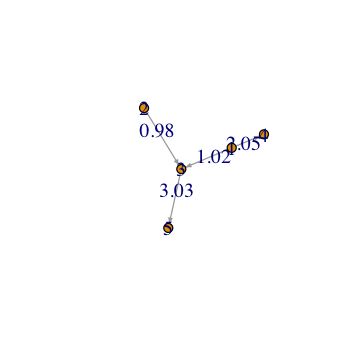

In [70]:
# LiNGAM Algorithm:
library(pcalg)

# Linear SCM with uniform distributed noise
set.seed(145)
N <- 2000
x1 <- runif(N,-.5,.5)
x2 <- runif(N,-.3,3)
x3 <- x1 + x2 + runif(N,-.7,.7)
x4 <- 2*x1 + runif(N,-.5,.5)
x5 <- 3*x3 + runif(N,-1,1)
data <- cbind(x1,x2,x3,x4,x5)

# Apply LiNGAM
fit.ex2 <- lingam(data)

# Transpose the matrix to correct edge directions
adj_matrix <- t(fit.ex2$Bpruned)

# Convert to igraph and plot
g <- graph_from_adjacency_matrix(
  adj_matrix,
  mode = "directed",
  weighted = TRUE
)
plot(g, edge.label = round(E(g)$weight, 2))  # Show rounded weights